# **Raeesa Amir 21336123**

# **Deep Learning assignment**

# **Metadata-Enhanced DistilBERT for Skincare Review Recommendation Prediction**

## Project Type

This project is a Natural Language Processing (NLP) deep learning project. The input is skincare customer review text and lightweight metadata, and the output is a binary recommendation prediction indicating whether a product is recommended or not recommended.

# Install and import packages

In [1]:
!pip install -q transformers datasets accelerate torchmetrics

import os
import re
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.0 MB/s eta 0:00:00
Device: cuda


# Upload Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_excel(
    '/content/drive/MyDrive/Colab Notebooks/DL dataset.xlsx')

# Explore the dataset

In [4]:
df.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [5]:
df.tail()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
8489,P467659,Couture Clutch Eyeshadow Palette,1070,Yves Saint Laurent,2790,4.4286,7.0,NaN,NaN,NaN,...,0,0,0,NaN,Makeup,Eye,Eye Palettes,0,NaN,NaN
8490,P500874,L'Homme Eau de Parfum,1070,Yves Saint Laurent,2319,4.6367,556.0,2 oz / 60 mL,Size + Concentration + Formulation,2 oz / 60 mL eau de parfum spray,...,0,0,0,"['Layerable Scent', 'Woody & Earthy Scent']",Fragrance,Men,Cologne,1,129.0,129.0
8491,P504428,Mon Paris Eau de Parfum Gift Set,1070,Yves Saint Laurent,1475,5.0000,2.0,NaN,NaN,NaN,...,1,1,0,NaN,Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
8492,P504448,Y Eau de Parfum Gift Set,1070,Yves Saint Laurent,840,NaN,NaN,NaN,NaN,NaN,...,1,0,0,NaN,Fragrance,Value & Gift Sets,Cologne Gift Sets,0,NaN,NaN
8493,P505461,Candy Glaze Lip Gloss Stick Duo with Hyaluroni...,1070,Yves Saint Laurent,193,NaN,NaN,.11 oz / 3.2 mL,Color,NaN,...,1,0,1,"['Hyaluronic Acid', 'High Shine Finish', 'Plum...",Makeup,Lip,Lip Gloss,0,NaN,NaN


In [6]:
df.shape

(8494, 27)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new   

# Data Cleaning

In [8]:
# Checking missing values


missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage (%)
sale_price_usd,8224,96.821286
value_price_usd,8043,94.690370
variation_desc,7244,85.283730
child_max_price,5740,67.577113
child_min_price,5740,67.577113
highlights,2207,25.983047
size,1631,19.201789
variation_value,1598,18.813280
variation_type,1444,17.000235
tertiary_category,990,11.655286


In [9]:
# Removing columns with very high missing values

# These columns have too many missing values and are not needed for this project.
# Removing them improves data quality and keeps the dataset focused.

columns_to_drop = [
    "sale_price_usd",
    "value_price_usd",
    "variation_desc",
    "child_max_price",
    "child_min_price"
]

df_clean = df.drop(columns=columns_to_drop)

print("Original shape:", df.shape)
print("Shape after dropping sparse columns:", df_clean.shape)

Original shape: (8494, 27)
Shape after dropping sparse columns: (8494, 22)


In [10]:
# Selecting useful columns

# These columns are useful for ingredient analysis, product filtering,
# recommendation ranking, and dataset description in the report.

useful_columns = [
    "product_id",
    "product_name",
    "brand_name",
    "loves_count",
    "rating",
    "reviews",
    "ingredients",
    "price_usd",
    "highlights",
    "primary_category",
    "secondary_category",
    "tertiary_category",
    "limited_edition",
    "new",
    "online_only",
    "out_of_stock",
    "sephora_exclusive"
]

product_df = df_clean[useful_columns].copy()

print("Selected dataset shape:", product_df.shape)
product_df.head()

Selected dataset shape: (8494, 17)


,product_id,product_name,brand_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,limited_edition,new,online_only,out_of_stock,sephora_exclusive
0,P473671,Fragrance Discovery Set,19-69,6320,3.6364,11.0,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,0,1,0,0
1,P473668,La Habana Eau de Parfum,19-69,3827,4.1538,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,0,0,1,0,0
2,P473662,Rainbow Bar Eau de Parfum,19-69,3253,4.2500,16.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,0,0,1,0,0
3,P473660,Kasbah Eau de Parfum,19-69,3018,4.4762,21.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,0,0,1,0,0
4,P473658,Purple Haze Eau de Parfum,19-69,2691,3.2308,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,0,0,1,0,0


In [11]:
# Filtering skincare products

# This project focuses only on skincare recommendation, so products from other primary categories are removed.

print("Primary category distribution:")
print(product_df["primary_category"].value_counts())

skincare_df = product_df[
    product_df["primary_category"] == "Skincare"
].copy()

print("\nSkincare dataset shape:", skincare_df.shape)
skincare_df.head()

Primary category distribution:
primary_category
Skincare           2420
Makeup             2369
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64

Skincare dataset shape: (2420, 17)


,product_id,product_name,brand_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,limited_edition,new,online_only,out_of_stock,sephora_exclusive
89,P439055,GENIUS Sleeping Collagen Moisturizer,Algenist,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,0,0,0,0,1
90,P421277,GENIUS Liquid Collagen Serum,Algenist,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,0,0,0,0,1
91,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,0,0,0,0,1
92,P432045,GENIUS Liquid Collagen Lip Treatment,Algenist,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,NaN,0,0,0,0,1
93,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,Algenist,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,0,0,0,0,0


In [12]:
# Check missing values in skincare subset

skincare_missing = pd.DataFrame({
    "Missing Values": skincare_df.isnull().sum(),
    "Missing Percentage (%)": skincare_df.isnull().mean() * 100
}).sort_values(by="Missing Percentage (%)", ascending=False)

skincare_missing

,Missing Values,Missing Percentage (%)
highlights,417,17.231405
tertiary_category,380,15.702479
ingredients,134,5.537190
reviews,69,2.851240
rating,69,2.851240
product_id,0,0.000000
loves_count,0,0.000000
product_name,0,0.000000
brand_name,0,0.000000
price_usd,0,0.000000


In [13]:
# Cleaning skincare product data

# Ingredients are essential for the explainable recommendation part.
# Therefore, products without ingredients are removed.

skincare_df = skincare_df.dropna(subset=["ingredients"])

# Ratings and review counts are used later for ranking products,
# so products without these values are removed.

skincare_df = skincare_df.dropna(subset=["rating", "reviews"])

# Fill missing text/category values with "Unknown"
# rather than removing more rows unnecessarily.

skincare_df["highlights"] = skincare_df["highlights"].fillna("Unknown")
skincare_df["secondary_category"] = skincare_df["secondary_category"].fillna("Unknown")
skincare_df["tertiary_category"] = skincare_df["tertiary_category"].fillna("Unknown")

# Reset index after cleaning
skincare_df = skincare_df.reset_index(drop=True)

print("Cleaned skincare dataset shape:", skincare_df.shape)
skincare_df.head()

Cleaned skincare dataset shape: (2224, 17)


,product_id,product_name,brand_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,limited_edition,new,online_only,out_of_stock,sephora_exclusive
0,P439055,GENIUS Sleeping Collagen Moisturizer,Algenist,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,0,0,0,0,1
1,P421277,GENIUS Liquid Collagen Serum,Algenist,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,0,0,0,0,1
2,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,Unknown,Skincare,Eye Care,Eye Creams & Treatments,0,0,0,0,1
3,P432045,GENIUS Liquid Collagen Lip Treatment,Algenist,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,Unknown,0,0,0,0,1
4,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,Algenist,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,0,0,0,0,0


In [14]:
skincare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          2224 non-null   object 
 1   product_name        2224 non-null   object 
 2   brand_name          2224 non-null   object 
 3   loves_count         2224 non-null   int64  
 4   rating              2224 non-null   float64
 5   reviews             2224 non-null   float64
 6   ingredients         2224 non-null   object 
 7   price_usd           2224 non-null   float64
 8   highlights          2224 non-null   object 
 9   primary_category    2224 non-null   object 
 10  secondary_category  2224 non-null   object 
 11  tertiary_category   2224 non-null   object 
 12  limited_edition     2224 non-null   int64  
 13  new                 2224 non-null   int64  
 14  online_only         2224 non-null   int64  
 15  out_of_stock        2224 non-null   int64  
 16  sephor

In [15]:
# Dataset statistics for report

print("Total products in original dataset:", df.shape[0])
print("Total skincare products after cleaning:", skincare_df.shape[0])
print("Number of skincare brands:", skincare_df["brand_name"].nunique())
print("Number of skincare categories:", skincare_df["secondary_category"].nunique())
print("Average rating:", round(skincare_df["rating"].mean(), 2))
print("Median rating:", round(skincare_df["rating"].median(), 2))
print("Average review count:", round(skincare_df["reviews"].mean(), 2))
print("Median review count:", round(skincare_df["reviews"].median(), 2))
print("Minimum price:", skincare_df["price_usd"].min())
print("Maximum price:", skincare_df["price_usd"].max())
print("Median price:", skincare_df["price_usd"].median())

Total products in original dataset: 8494
Total skincare products after cleaning: 2224
Number of skincare brands: 133
Number of skincare categories: 13
Average rating: 4.23
Median rating: 4.31
Average review count: 480.47
Median review count: 173.0
Minimum price: 3.0
Maximum price: 449.0
Median price: 44.0


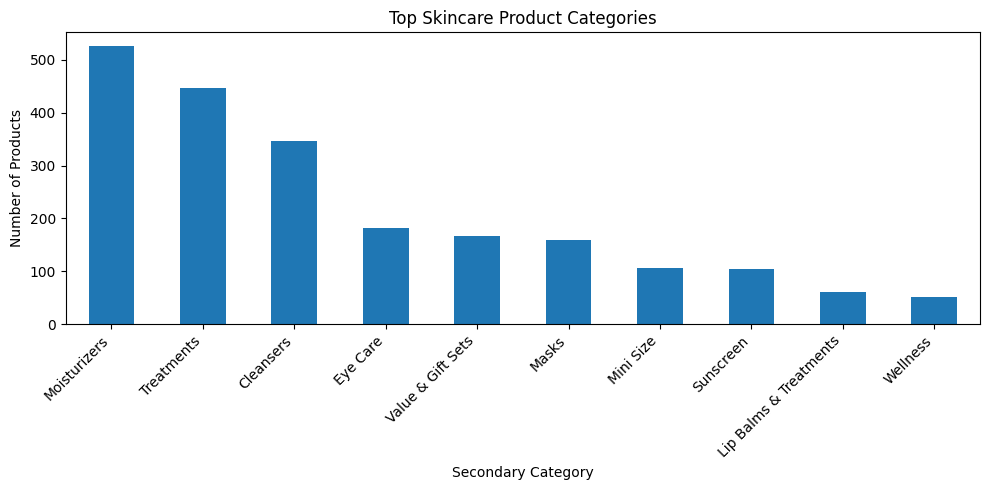

In [16]:
# Visualise skincare category distribution

plt.figure(figsize=(10, 5))

skincare_df["secondary_category"].value_counts().head(10).plot(kind="bar")

plt.title("Top Skincare Product Categories")
plt.xlabel("Secondary Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

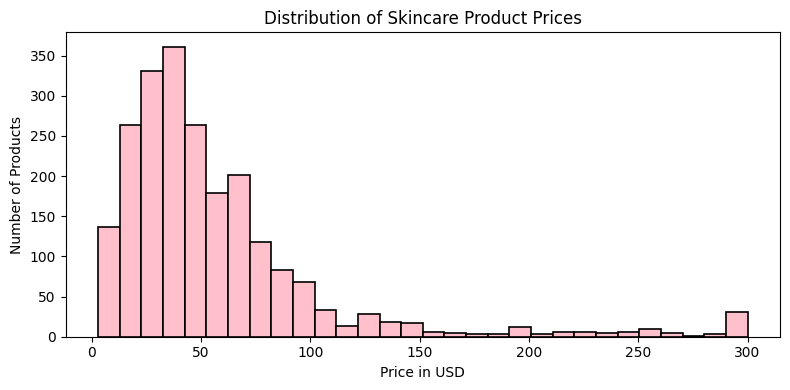

In [17]:
# Visualising price distribution

# Prices are clipped at 300 USD only for visualisation.
# This avoids extreme outliers making the graph unreadable.

plt.figure(figsize=(8, 4))

skincare_df["price_usd"].clip(upper=300).plot(
    kind="hist",
    bins=30,
    color="pink",
    edgecolor="black",
    linewidth=1.2
)

plt.title("Distribution of Skincare Product Prices")
plt.xlabel("Price in USD")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

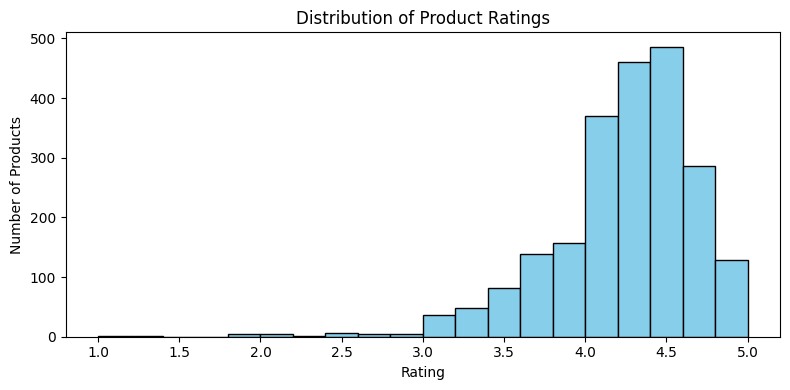

In [18]:
# Visualise product ratings


plt.figure(figsize=(8, 4))

skincare_df["rating"].plot(
    kind="hist",
    bins=20,
    color="skyblue",
    edgecolor="black",
    linewidth=1
)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

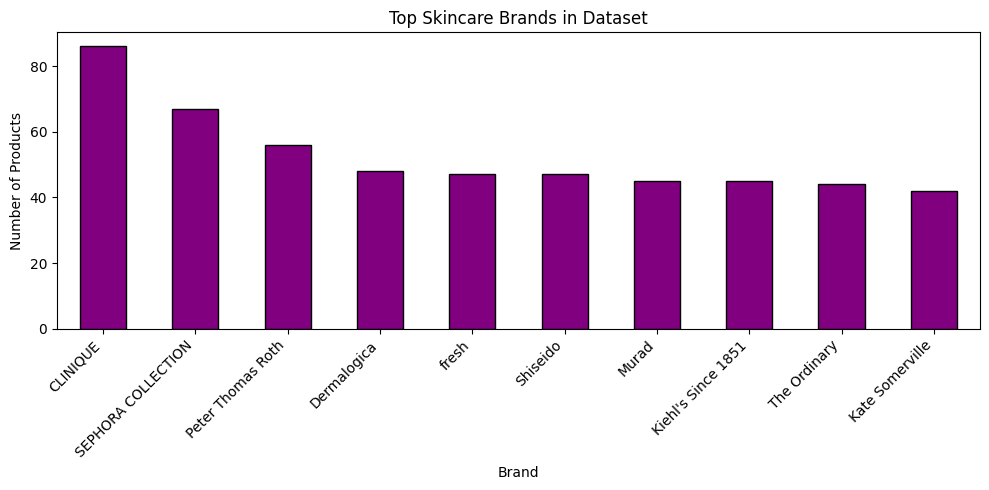

In [19]:
# Top skincare brands


top_brands = skincare_df["brand_name"].value_counts().head(10)

plt.figure(figsize=(10, 5))

top_brands.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Top Skincare Brands in Dataset")
plt.xlabel("Brand")
plt.ylabel("Number of Products")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

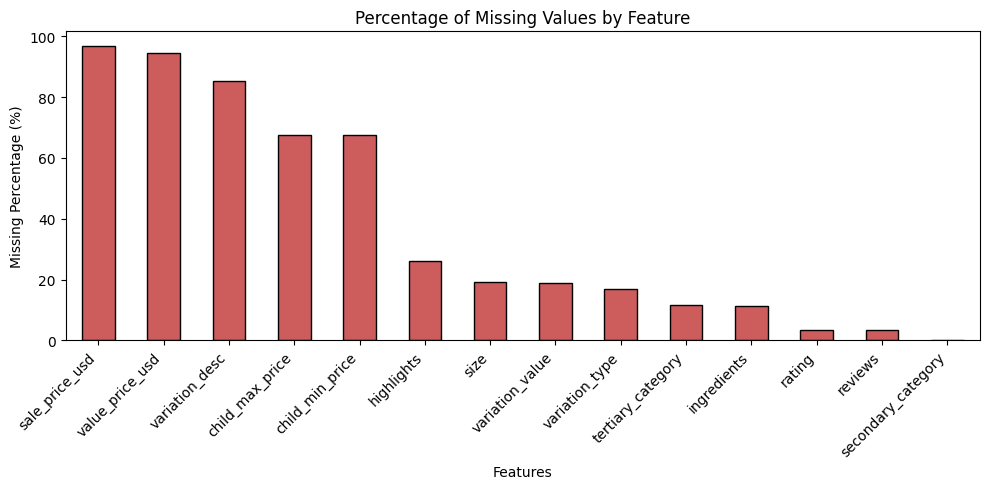

In [20]:
import seaborn as sns

# Missing values heatmap


missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

# Keep only columns with missing values
missing_percentage = missing_percentage[
    missing_percentage > 0
]

plt.figure(figsize=(10, 5))

missing_percentage.plot(
    kind="bar",
    color="indianred",
    edgecolor="black"
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

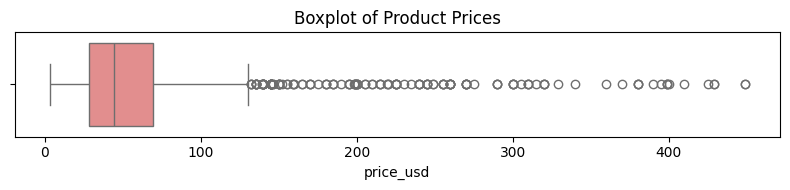

In [21]:
# Price outlier analysis


plt.figure(figsize=(8, 2))

sns.boxplot(
    x=skincare_df["price_usd"],
    color="lightcoral"
)

plt.title("Boxplot of Product Prices")

plt.tight_layout()
plt.show()

In [22]:
# Showing example product records

example_products = skincare_df[
    [
        "product_name",
        "brand_name",
        "secondary_category",
        "rating",
        "reviews",
        "price_usd",
        "ingredients"
    ]
].head(5)

example_products

,product_name,brand_name,secondary_category,rating,reviews,price_usd,ingredients
0,GENIUS Sleeping Collagen Moisturizer,Algenist,Moisturizers,4.5413,1321.0,98.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh..."
1,GENIUS Liquid Collagen Serum,Algenist,Treatments,4.0259,1159.0,115.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan..."
2,Triple Algae Eye Renewal Balm Eye Cream,Algenist,Eye Care,4.5306,1142.0,68.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is..."
3,GENIUS Liquid Collagen Lip Treatment,Algenist,Lip Balms & Treatments,3.8721,649.0,29.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer..."
4,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,Algenist,Sunscreen,4.4134,508.0,28.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O..."


In [23]:
# Saving cleaned skincare product dataset


skincare_df.to_csv("/content/cleaned_skincare_products.csv", index=False)

print("Cleaned skincare product dataset saved successfully.")

Cleaned skincare product dataset saved successfully.


# Review csv files

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os

project_path = "/content/drive/MyDrive/DeepLearningProject"

print(os.listdir(project_path))

['product_info.csv.zip', 'reviews_0-250_masked.csv.zip', 'reviews_250-500_masked.csv.zip', 'reviews_500-750_masked.csv.zip', 'reviews_750-1250_masked.csv.zip', 'reviews_1250-end_masked.csv (1).zip']


In [26]:
# Extracting review ZIP files


import zipfile
import glob
import os

# Folder where the review ZIP files are saved
project_path = "/content/drive/MyDrive/DeepLearningProject"

# Folder where the extracted CSV files will be stored temporarily in Colab
extract_path = "/content/review_data"

os.makedirs(extract_path, exist_ok=True)

# Find all ZIP files in the project folder
zip_files = glob.glob(project_path + "/*.zip")

print("ZIP files found:")
print(zip_files)

# Extract each ZIP file
for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

print("All ZIP files extracted successfully.")

ZIP files found:
['/content/drive/MyDrive/DeepLearningProject/product_info.csv.zip', '/content/drive/MyDrive/DeepLearningProject/reviews_0-250_masked.csv.zip', '/content/drive/MyDrive/DeepLearningProject/reviews_250-500_masked.csv.zip', '/content/drive/MyDrive/DeepLearningProject/reviews_500-750_masked.csv.zip', '/content/drive/MyDrive/DeepLearningProject/reviews_750-1250_masked.csv.zip', '/content/drive/MyDrive/DeepLearningProject/reviews_1250-end_masked.csv (1).zip']
All ZIP files extracted successfully.


In [27]:
# Checking extracted CSV files

review_files = glob.glob(extract_path + "/*.csv")

print("CSV files found:")
print(review_files)
print("Number of CSV files:", len(review_files))

CSV files found:
['/content/review_data/reviews_0-250_masked.csv', '/content/review_data/reviews_250-500_masked.csv', '/content/review_data/reviews_750-1250_masked.csv', '/content/review_data/product_info.csv', '/content/review_data/reviews_1250-end_masked.csv', '/content/review_data/reviews_500-750_masked.csv']
Number of CSV files: 6


In [28]:
# Combining review datasets


review_df = pd.concat(
    [pd.read_csv(file, low_memory=False) for file in review_files],
    ignore_index=True
)

print("Combined review dataset shape:", review_df.shape)

review_df.head()

Combined review dataset shape: (293906, 41)


,Unnamed: 0.1,Unnamed: 0,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,0.0,0.0,5.0,1.0,1.0,2.0,0.0,2.0,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,0.0,NaN,0.0,0.0,0.0,2023-03-21,I bought this lip mask after reading the revie...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,2.0,5.0,1.0,NaN,0.0,0.0,0.0,2023-03-21,My review title says it all! I get so excited ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,3.0,5.0,1.0,NaN,0.0,0.0,0.0,2023-03-20,I’ve always loved this formula for a long time...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,4.0,5.0,1.0,NaN,0.0,0.0,0.0,2023-03-20,"If you have dry cracked lips, this is a must h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Inspecting review dataset


print("Review dataset columns:")
print(review_df.columns.tolist())

review_df.info()

Review dataset columns:
['Unnamed: 0.1', 'Unnamed: 0', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd', 'brand_id', 'loves_count', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293906 entries, 0 to 293905
Data columns (total 41 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0.1              285412 non-null  float64
 1   Unnamed: 0       

# Clean review files

In [30]:
# Select useful review columns

# These are the columns needed for the NLP classification task.
# review_text is the model input.
# is_recommended is the target label.
# product_id allows reviews to be linked back to product ingredients.

useful_review_columns = [
    "product_id",
    "review_text",
    "review_title",
    "is_recommended",
    "rating",
    "skin_type",
    "helpfulness",
    "total_feedback_count",
    "total_pos_feedback_count",
    "total_neg_feedback_count"
]

# Keep only columns that exist in the dataset.
useful_review_columns = [
    col for col in useful_review_columns if col in review_df.columns
]

review_df = review_df[useful_review_columns].copy()

print("Selected review dataset shape:", review_df.shape)
review_df.head()

Selected review dataset shape: (293906, 10)


,product_id,review_text,review_title,is_recommended,rating,skin_type,helpfulness,total_feedback_count,total_pos_feedback_count,total_neg_feedback_count
0,P504322,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,1.0,5.0,dry,1.0,2.0,2.0,0.0
1,P420652,I bought this lip mask after reading the revie...,Disappointed,0.0,1.0,NaN,NaN,0.0,0.0,0.0
2,P420652,My review title says it all! I get so excited ...,New Favorite Routine,1.0,5.0,dry,NaN,0.0,0.0,0.0
3,P420652,I’ve always loved this formula for a long time...,Can't go wrong with any of them,1.0,5.0,combination,NaN,0.0,0.0,0.0
4,P420652,"If you have dry cracked lips, this is a must h...",A must have !!!,1.0,5.0,combination,NaN,0.0,0.0,0.0


In [31]:
# Checking missing values in review data

review_missing = pd.DataFrame({
    "Missing Values": review_df.isnull().sum(),
    "Missing Percentage (%)": review_df.isnull().mean() * 100
}).sort_values(by="Missing Percentage (%)", ascending=False)

review_missing

,Missing Values,Missing Percentage (%)
helpfulness,162816,55.397304
review_title,88188,30.005512
is_recommended,65726,22.362932
skin_type,45368,15.436228
review_text,8839,3.007424
total_pos_feedback_count,8494,2.890040
total_neg_feedback_count,8494,2.890040
total_feedback_count,8494,2.890040
rating,278,0.094588
product_id,0,0.000000


In [32]:
# Cleaning review dataset

# Keeping a copy of the original dataset size for reporting.
original_review_rows = review_df.shape[0]

# Remove rows without review text because NLP models require text input.
review_df = review_df.dropna(subset=["review_text"])

# Remove rows without recommendation labels.
# Supervised learning requires a target label.
review_df = review_df.dropna(subset=["is_recommended"])

# Convert review text into string format.
review_df["review_text"] = review_df["review_text"].astype(str)

# Convert recommendation labels into integers.
# 1 = recommended
# 0 = not recommended
review_df["is_recommended"] = review_df["is_recommended"].astype(int)

# Fill missing review titles with placeholder text.
review_df["review_title"] = review_df["review_title"].fillna("No title")

# Fill missing skin types with Unknown.
review_df["skin_type"] = review_df["skin_type"].fillna("Unknown")

# Remove duplicate reviews for the same product.
review_df = review_df.drop_duplicates(
    subset=["product_id", "review_text"]
)

# Reset index after cleaning.
review_df = review_df.reset_index(drop=True)

print("Rows before cleaning:", original_review_rows)
print("Rows after cleaning:", review_df.shape[0])
print("Rows removed:", original_review_rows - review_df.shape[0])


Rows before cleaning: 293906
Rows after cleaning: 227662
Rows removed: 66244


In [33]:
review_df.head()

,product_id,review_text,review_title,is_recommended,rating,skin_type,helpfulness,total_feedback_count,total_pos_feedback_count,total_neg_feedback_count
0,P504322,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,1,5.0,dry,1.0,2.0,2.0,0.0
1,P420652,I bought this lip mask after reading the revie...,Disappointed,0,1.0,Unknown,NaN,0.0,0.0,0.0
2,P420652,My review title says it all! I get so excited ...,New Favorite Routine,1,5.0,dry,NaN,0.0,0.0,0.0
3,P420652,I’ve always loved this formula for a long time...,Can't go wrong with any of them,1,5.0,combination,NaN,0.0,0.0,0.0
4,P420652,"If you have dry cracked lips, this is a must h...",A must have !!!,1,5.0,combination,NaN,0.0,0.0,0.0


In [34]:
# Creating review length feature

# Review length helps identify extremely short or noisy reviews.

review_df["review_length"] = review_df["review_text"].apply(
    lambda text: len(str(text).split())
)

review_df[
    ["review_text", "review_length", "is_recommended"]
].head()

,review_text,review_length,is_recommended
0,I use this with the Nudestix “Citrus Clean Bal...,79,1
1,I bought this lip mask after reading the revie...,28,0
2,My review title says it all! I get so excited ...,53,1
3,I’ve always loved this formula for a long time...,45,1
4,"If you have dry cracked lips, this is a must h...",46,1


In [35]:
# Removing very short reviews

# Reviews shorter than 3 words usually contain little useful information.

before_short_filter = review_df.shape[0]

review_df = review_df[
    review_df["review_length"] >= 3
].copy()

review_df = review_df.reset_index(drop=True)

after_short_filter = review_df.shape[0]

print("Rows before filtering:", before_short_filter)
print("Rows after filtering:", after_short_filter)
print("Short reviews removed:", before_short_filter - after_short_filter)

Rows before filtering: 227662
Rows after filtering: 227643
Short reviews removed: 19


In [36]:
# Analyse recommendation label balance

label_counts = review_df["is_recommended"] \
    .value_counts() \
    .sort_index()

label_percentages = (
    review_df["is_recommended"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

label_summary = pd.DataFrame({
    "Count": label_counts,
    "Percentage (%)": label_percentages
})

label_summary

,Count,Percentage (%)
is_recommended,,
0,35563,15.622268
1,192080,84.377732


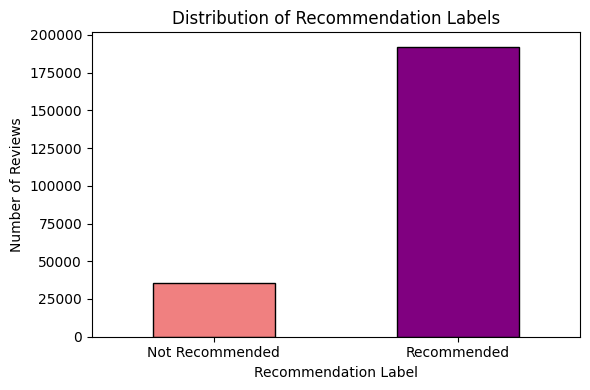

In [37]:
# Recommendation label distribution

plt.figure(figsize=(6, 4))

label_counts.plot(
    kind="bar",
    color=["lightcoral", "purple"],
    edgecolor="black"
)

plt.title("Distribution of Recommendation Labels")
plt.xlabel("Recommendation Label")
plt.ylabel("Number of Reviews")

plt.xticks(
    ticks=[0, 1],
    labels=["Not Recommended", "Recommended"],
    rotation=0
)

plt.tight_layout()
plt.show()

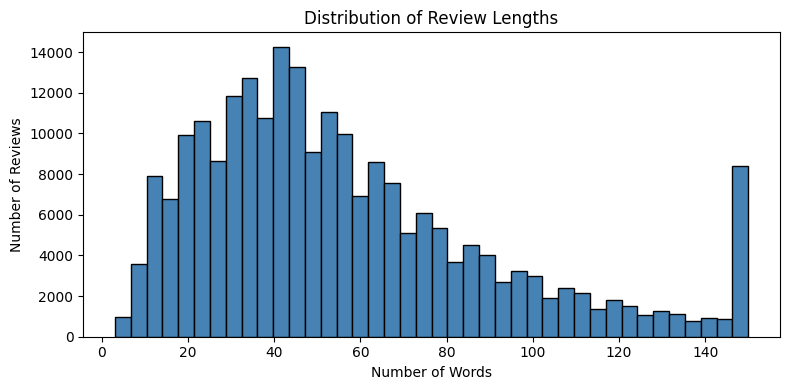

In [38]:
# Review length distribution


plt.figure(figsize=(8, 4))

review_df["review_length"].clip(upper=150).plot(
    kind="hist",
    bins=40,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

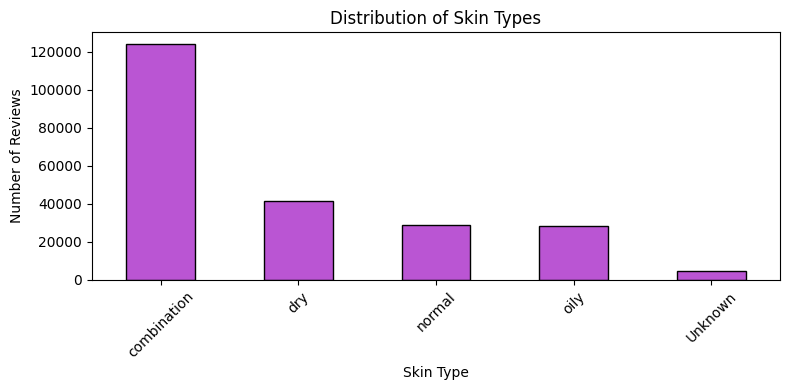

In [39]:
# Skin type distribution


skin_counts = review_df["skin_type"].value_counts()

plt.figure(figsize=(8, 4))

skin_counts.plot(
    kind="bar",
    color="mediumorchid",
    edgecolor="black"
)

plt.title("Distribution of Skin Types")
plt.xlabel("Skin Type")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

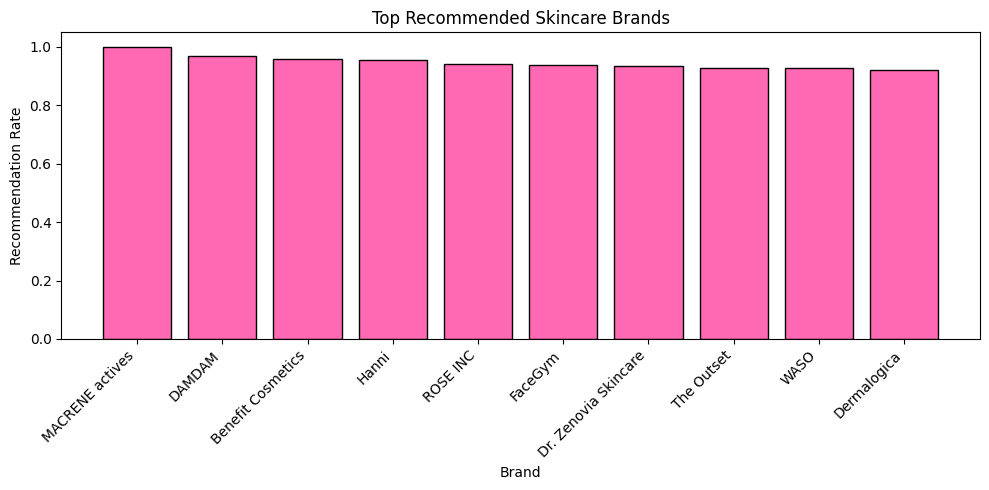

In [40]:
merged_df = pd.merge(skincare_df, review_df, on="product_id", how="inner")

brand_recommendation = merged_df.groupby("brand_name").agg(
    recommendation_rate=("is_recommended", "mean"),
    review_count=("review_text", "count")
)

# Filter for brands with a minimum number of reviews (e.g., 50 reviews) to make recommendations more robust
brand_recommendation = brand_recommendation[
    brand_recommendation["review_count"] >= 50
]

top_recommended_brands = brand_recommendation.sort_values(
    by=["recommendation_rate", "review_count"],
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_recommended_brands.index,
    top_recommended_brands["recommendation_rate"],
    color="hotpink",
    edgecolor="black"
)

plt.title("Top Recommended Skincare Brands")
plt.xlabel("Brand")
plt.ylabel("Recommendation Rate")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

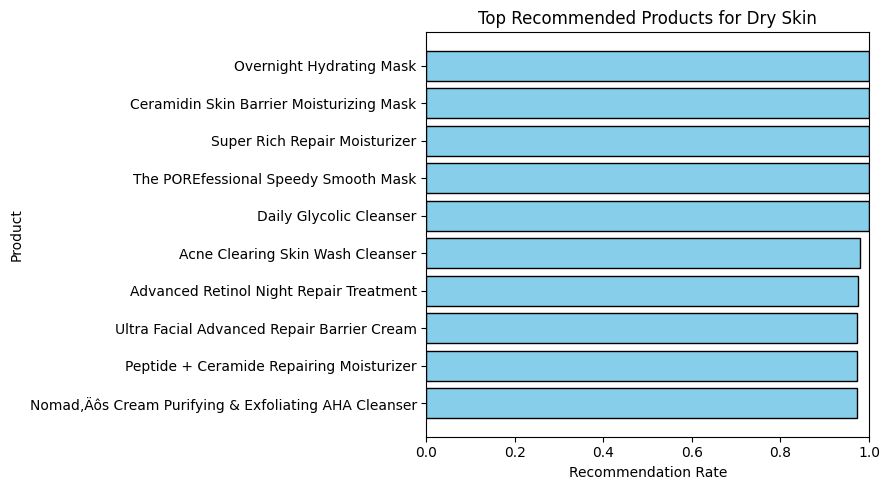

In [41]:
# Top recommended products for dry skin
dry_skin_df = merged_df[
    merged_df["skin_type"].str.lower() == "dry"
]

dry_products = dry_skin_df.groupby("product_name").agg(
    recommendation_rate=("is_recommended", "mean"),
    review_count=("review_text", "count")
)

# Keep only products with enough reviews
dry_products = dry_products[
    dry_products["review_count"] >= 30
]

top_dry_products = dry_products.sort_values(
    by=["recommendation_rate", "review_count"],
    ascending=False
).head(10)

plt.figure(figsize=(9, 5))

plt.barh(
    top_dry_products.index,
    top_dry_products["recommendation_rate"],
    color="skyblue",
    edgecolor="black"
)

plt.title("Top Recommended Products for Dry Skin")
plt.xlabel("Recommendation Rate")
plt.ylabel("Product")
plt.xlim(0, 1)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

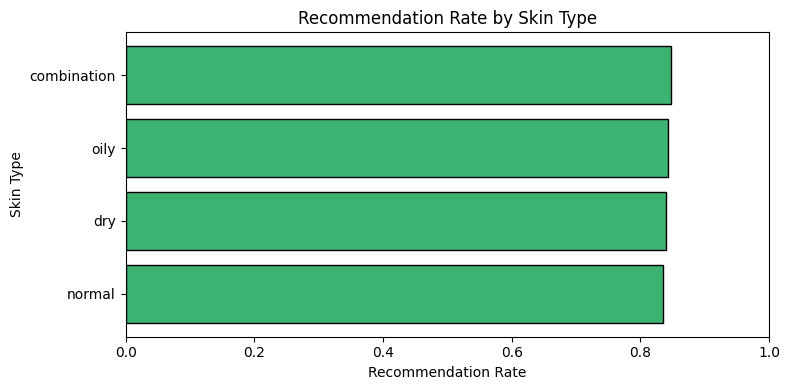

In [42]:
# Recommendation rate by skin type

skin_recommendation = merged_df.groupby("skin_type").agg(
    recommendation_rate=("is_recommended", "mean"),
    review_count=("review_text", "count")
)

# Remove Unknown if you want cleaner analysis
skin_recommendation = skin_recommendation.drop(index="Unknown", errors="ignore")

skin_recommendation = skin_recommendation.sort_values(
    by="recommendation_rate",
    ascending=True
)

plt.figure(figsize=(8, 4))

plt.barh(
    skin_recommendation.index,
    skin_recommendation["recommendation_rate"],
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Recommendation Rate by Skin Type")
plt.xlabel("Recommendation Rate")
plt.ylabel("Skin Type")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [43]:
# Prepare input and output data

# The input to the models is the customer review text.
X = review_df["review_text"]

# The output label is whether the product was recommended.
# 0 = not recommended, 1 = recommended
y = review_df["is_recommended"]

print("Number of reviews:", X.shape[0])
print("Number of labels:", y.shape[0])

print("\nClass distribution:")
print(y.value_counts())

Number of reviews: 227643
Number of labels: 227643

Class distribution:
is_recommended
1    192080
0     35563
Name: count, dtype: int64


# Train, validation and test split

In [44]:
# Train, validation and test split

from sklearn.model_selection import train_test_split

# First, split off the final test set.
# The test set is kept separate and only used for final evaluation.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Then split the remaining data into training and validation sets.
# This gives 64% train, 16% validation and 20% test overall.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation label distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 145691
Validation samples: 36423
Test samples: 45529

Training label distribution:
is_recommended
1    0.843779
0    0.156221
Name: proportion, dtype: float64

Validation label distribution:
is_recommended
1    0.84378
0    0.15622
Name: proportion, dtype: float64

Test label distribution:
is_recommended
1    0.84377
0    0.15623
Name: proportion, dtype: float64


**TF-IDF vectorisation**

In [45]:
# TF-IDF vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF converts text into numerical features for traditional ML models.
# Unigrams and bigrams are used so the model can learn single words
# and short phrases such as "dry skin" or "break out".

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Fit only on training data to avoid data leakage.
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test data using the same fitted vocabulary.
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (145691, 10000)
Validation TF-IDF shape: (36423, 10000)
Test TF-IDF shape: (45529, 10000)


In [46]:
# Evaluation function

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate model performance using standard classification metrics.
    These metrics are used because accuracy alone can be misleading
    when the dataset is imbalanced.
    """

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{model_name} Results")
    print("-" * 40)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

# Model 1: Logistic Regression + TF-IDF

In [47]:
# Logistic Regression


from sklearn.linear_model import LogisticRegression

# Logistic Regression is used as the first baseline model.
# class_weight="balanced" helps handle the imbalance between recommended
# and not recommended reviews.

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train the model using TF-IDF features.
logistic_model.fit(X_train_tfidf, y_train)

# Predict on validation data.
logistic_val_pred = logistic_model.predict(X_val_tfidf)

# Evaluate validation performance.
logistic_results = evaluate_model(
    "TF-IDF + Logistic Regression",
    y_val,
    logistic_val_pred
)


TF-IDF + Logistic Regression Results
----------------------------------------
Accuracy: 0.9081
Precision: 0.9786
Recall: 0.9109
F1-score: 0.9436

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.89      0.75      5690
           1       0.98      0.91      0.94     30733

    accuracy                           0.91     36423
   macro avg       0.81      0.90      0.85     36423
weighted avg       0.93      0.91      0.91     36423



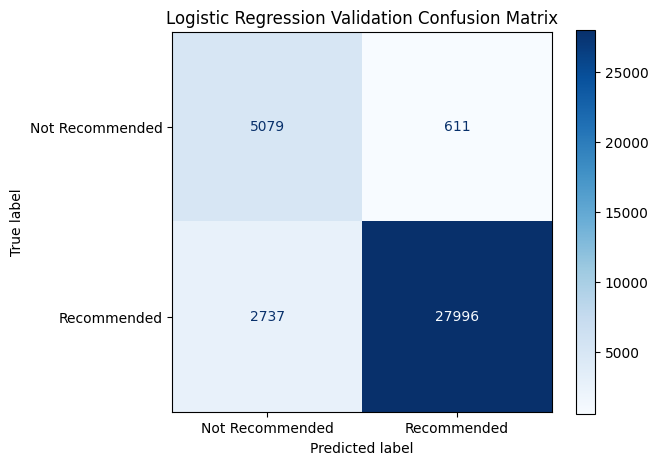

In [48]:
# Logistic Regression confusion matrix

import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_val,
    logistic_val_pred,
    display_labels=["Not Recommended", "Recommended"],
    cmap="Blues"
)

plt.title("Logistic Regression Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# Model 2: Linear SVM baseline

In [49]:
# Model 2: Linear SVM

from sklearn.svm import LinearSVC

# Linear SVM is a strong baseline for high-dimensional text data.
# It is commonly used with TF-IDF features for text classification.

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

# Train the SVM model.
svm_model.fit(X_train_tfidf, y_train)

# Predict on validation data.
svm_val_pred = svm_model.predict(X_val_tfidf)

# Evaluate validation performance.
svm_results = evaluate_model(
    "TF-IDF + Linear SVM",
    y_val,
    svm_val_pred
)


TF-IDF + Linear SVM Results
----------------------------------------
Accuracy: 0.9095
Precision: 0.9756
Recall: 0.9156
F1-score: 0.9447

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.88      0.75      5690
           1       0.98      0.92      0.94     30733

    accuracy                           0.91     36423
   macro avg       0.82      0.90      0.85     36423
weighted avg       0.93      0.91      0.91     36423



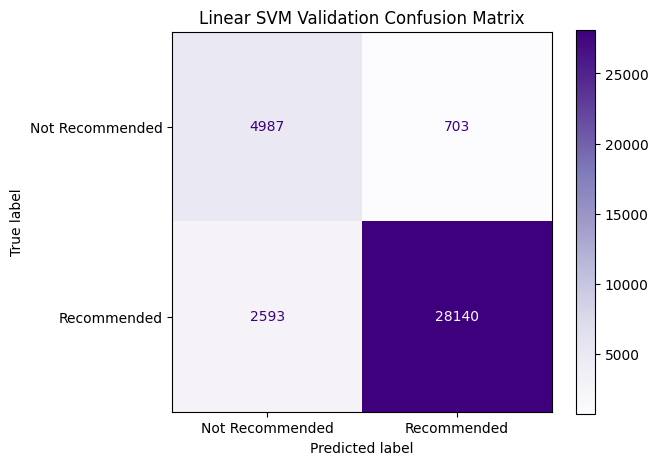

In [50]:
# Linear SVM confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_val,
    svm_val_pred,
    display_labels=["Not Recommended", "Recommended"],
    cmap="Purples"
)

plt.title("Linear SVM Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [51]:
# Compare baseline validation results

baseline_results = pd.DataFrame([
    logistic_results,
    svm_results
])

baseline_results

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.908080,0.978642,0.910943,0.943579
1,TF-IDF + Linear SVM,0.909508,0.975627,0.915628,0.944676


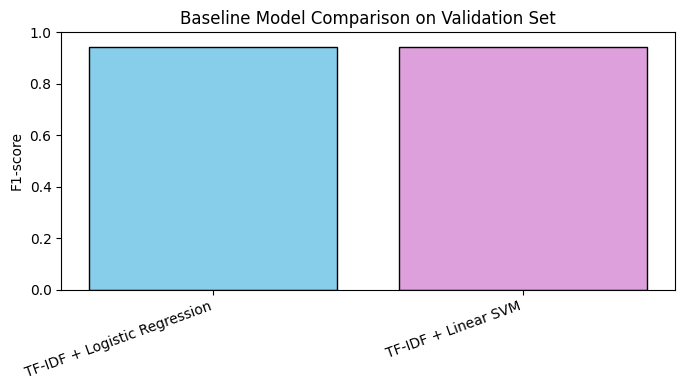

In [52]:
# Baseline model comparison

plt.figure(figsize=(7, 4))

plt.bar(
    baseline_results["Model"],
    baseline_results["F1-score"],
    color=["skyblue", "plum"],
    edgecolor="black"
)

plt.title("Baseline Model Comparison on Validation Set")
plt.ylabel("F1-score")
plt.ylim(0, 1)

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

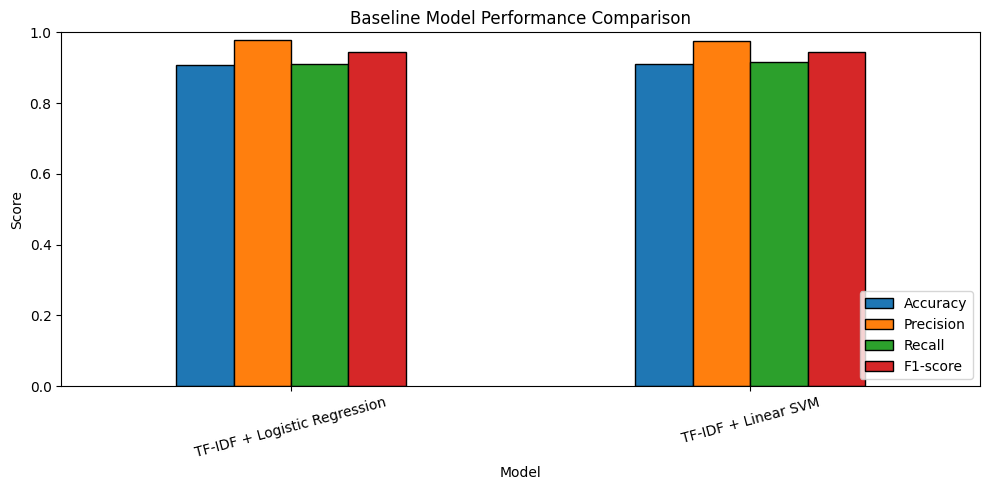

In [53]:
# Multi-metric baseline comparison

comparison_metrics = baseline_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
]

comparison_metrics.plot(
    kind="bar",
    figsize=(10, 5),
    edgecolor="black"
)

plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [54]:
# Final test evaluation using best baseline model

# Predict on unseen test data
svm_test_pred = svm_model.predict(X_test_tfidf)

# Evaluate final test performance
svm_test_results = evaluate_model(
    "Final Linear SVM Test Results",
    y_test,
    svm_test_pred
)


Final Linear SVM Test Results Results
----------------------------------------
Accuracy: 0.911
Precision: 0.9761
Recall: 0.9169
F1-score: 0.9456

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.88      0.76      7113
           1       0.98      0.92      0.95     38416

    accuracy                           0.91     45529
   macro avg       0.82      0.90      0.85     45529
weighted avg       0.93      0.91      0.92     45529



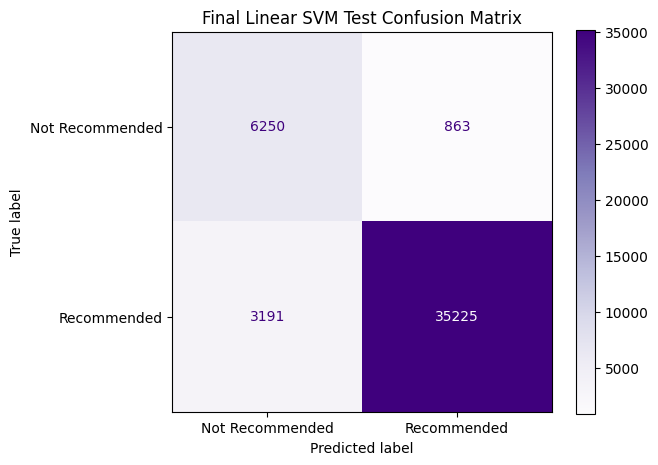

In [55]:
# Final SVM test confusion matrix


ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_test_pred,
    display_labels=["Not Recommended", "Recommended"],
    cmap="Purples"
)

plt.title("Final Linear SVM Test Confusion Matrix")

plt.tight_layout()
plt.show()

# Model 3: DistilBert

In [56]:
# Install transformer libraries


!pip install -q transformers datasets accelerate

In [57]:
# Import transformer libraries


from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

import torch

In [58]:
# Stratified subset for controlled transformer experiments

bert_train_size = 12000
bert_val_size = 3000
bert_test_size = 3000

# Keep metadata aligned with the same review indexes
metadata_df = review_df[["review_length", "skin_type", "rating"]].copy()

train_idx, _ = train_test_split(
    X_train.index,
    train_size=bert_train_size,
    stratify=y_train.loc[X_train.index],
    random_state=SEED
)

val_idx, _ = train_test_split(
    X_val.index,
    train_size=bert_val_size,
    stratify=y_val.loc[X_val.index],
    random_state=SEED
)

test_idx, _ = train_test_split(
    X_test.index,
    train_size=bert_test_size,
    stratify=y_test.loc[X_test.index],
    random_state=SEED
)

X_train_bert = X_train.loc[train_idx]
y_train_bert = y_train.loc[train_idx]
meta_train_bert = metadata_df.loc[train_idx].copy()

X_val_bert = X_val.loc[val_idx]
y_val_bert = y_val.loc[val_idx]
meta_val_bert = metadata_df.loc[val_idx].copy()

X_test_bert = X_test.loc[test_idx]
y_test_bert = y_test.loc[test_idx]
meta_test_bert = metadata_df.loc[test_idx].copy()

print("Controlled DistilBERT training samples:", len(X_train_bert))
print("Controlled DistilBERT validation samples:", len(X_val_bert))
print("Controlled DistilBERT test samples:", len(X_test_bert))

print("\nTraining label balance:")
print(y_train_bert.value_counts(normalize=True))

print("\nValidation label balance:")
print(y_val_bert.value_counts(normalize=True))

print("\nTest label balance:")
print(y_test_bert.value_counts(normalize=True))

Controlled DistilBERT training samples: 12000
Controlled DistilBERT validation samples: 3000
Controlled DistilBERT test samples: 3000

Training label balance:
is_recommended
1    0.84375
0    0.15625
Name: proportion, dtype: float64

Validation label balance:
is_recommended
1    0.843667
0    0.156333
Name: proportion, dtype: float64

Test label balance:
is_recommended
1    0.843667
0    0.156333
Name: proportion, dtype: float64


In [59]:
# Controlled TF-IDF baselines using same split as DistilBERT

# These baselines are trained on the same 12k training subset
# and tested on the same 3k test subset as DistilBERT.
# This makes the final comparison fair.

tfidf_controlled = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_controlled_tfidf = tfidf_controlled.fit_transform(X_train_bert)
X_val_controlled_tfidf = tfidf_controlled.transform(X_val_bert)
X_test_controlled_tfidf = tfidf_controlled.transform(X_test_bert)

print("Controlled TF-IDF train shape:", X_train_controlled_tfidf.shape)
print("Controlled TF-IDF validation shape:", X_val_controlled_tfidf.shape)
print("Controlled TF-IDF test shape:", X_test_controlled_tfidf.shape)

Controlled TF-IDF train shape: (12000, 10000)
Controlled TF-IDF validation shape: (3000, 10000)
Controlled TF-IDF test shape: (3000, 10000)


In [60]:
# Controlled Logistic Regression baseline

controlled_logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

controlled_logistic_model.fit(
    X_train_controlled_tfidf,
    y_train_bert
)

controlled_logistic_pred = controlled_logistic_model.predict(
    X_test_controlled_tfidf
)

controlled_logistic_results = evaluate_model(
    "TF-IDF + Logistic Regression controlled split",
    y_test_bert,
    controlled_logistic_pred
)


TF-IDF + Logistic Regression controlled split Results
----------------------------------------
Accuracy: 0.888
Precision: 0.9645
Recall: 0.9004
F1-score: 0.9313

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.82      0.70       469
           1       0.96      0.90      0.93      2531

    accuracy                           0.89      3000
   macro avg       0.78      0.86      0.81      3000
weighted avg       0.91      0.89      0.89      3000



In [61]:
# Controlled Linear SVM baseline

controlled_svm_model = LinearSVC(
    class_weight="balanced",
    random_state=SEED
)

controlled_svm_model.fit(
    X_train_controlled_tfidf,
    y_train_bert
)

controlled_svm_pred = controlled_svm_model.predict(
    X_test_controlled_tfidf
)

controlled_svm_results = evaluate_model(
    "TF-IDF + Linear SVM controlled split",
    y_test_bert,
    controlled_svm_pred
)


TF-IDF + Linear SVM controlled split Results
----------------------------------------
Accuracy: 0.902
Precision: 0.9527
Recall: 0.9301
F1-score: 0.9412

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71       469
           1       0.95      0.93      0.94      2531

    accuracy                           0.90      3000
   macro avg       0.81      0.84      0.82      3000
weighted avg       0.91      0.90      0.90      3000



In [62]:
# Create HuggingFace datasets

train_dataset = Dataset.from_dict({
    "text": X_train_bert.tolist(),
    "label": y_train_bert.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val_bert.tolist(),
    "label": y_val_bert.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test_bert.tolist(),
    "label": y_test_bert.tolist()
})

In [63]:
# Load DistilBERT tokenizer


tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [64]:
# Tokenise review text

def tokenize_function(example):

    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function)
val_dataset = val_dataset.map(tokenize_function)
test_dataset = test_dataset.map(tokenize_function)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [65]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [66]:
# Load DistilBERT model

from transformers import DistilBertForSequenceClassification

# DistilBERT is used as the main deep learning model.
# It predicts whether a skincare review recommends the product or not.

distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [67]:
# Define evaluation metrics

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    """
    Calculate standard classification metrics.
    F1-score is important because the recommendation labels are imbalanced.
    """

    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [68]:
# Set DistilBERT training arguments

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_results",

    # Evaluate and save model after each epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # Standard fine-tuning settings for transformer classification
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    # Keep the model with the best validation F1-score
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Logging
    logging_dir="./logs",
    logging_steps=50,
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [69]:
# Create Trainer

from transformers import Trainer

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [70]:
# Train DistilBERT

train_output = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.175412,0.156783,0.943667,0.954580,0.979850,0.967050
2,0.128617,0.179164,0.950000,0.971859,0.968787,0.970321
3,0.058531,0.205870,0.951333,0.968934,0.973528,0.971226


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [71]:
# Evaluate DistilBERT on validation set

distilbert_val_results = trainer.evaluate(val_dataset)

distilbert_val_results

{'eval_loss': 0.20587030053138733,
 'eval_accuracy': 0.9513333333333334,
 'eval_precision': 0.9689343295320487,
 'eval_recall': 0.9735282497036745,
 'eval_f1': 0.9712258573117856,
 'eval_runtime': 11.9107,
 'eval_samples_per_second': 251.875,
 'eval_steps_per_second': 15.784,
 'epoch': 3.0}

In [72]:
# Evaluate DistilBERT on test set

distilbert_test_results = trainer.evaluate(test_dataset)

distilbert_test_results

{'eval_loss': 0.20796558260917664,
 'eval_accuracy': 0.9473333333333334,
 'eval_precision': 0.9687870406953774,
 'eval_recall': 0.9687870406953774,
 'eval_f1': 0.9687870406953774,
 'eval_runtime': 12.8264,
 'eval_samples_per_second': 233.892,
 'eval_steps_per_second': 14.657,
 'epoch': 3.0}

In [73]:
# DistilBERT test predictions

predictions = trainer.predict(test_dataset)

y_test_bert = predictions.label_ids
y_pred_bert = predictions.predictions.argmax(axis=1)

print(classification_report(
    y_test_bert,
    y_pred_bert,
    target_names=["Not Recommended", "Recommended"]
))

                 precision    recall  f1-score   support

Not Recommended       0.83      0.83      0.83       469
    Recommended       0.97      0.97      0.97      2531

       accuracy                           0.95      3000
      macro avg       0.90      0.90      0.90      3000
   weighted avg       0.95      0.95      0.95      3000



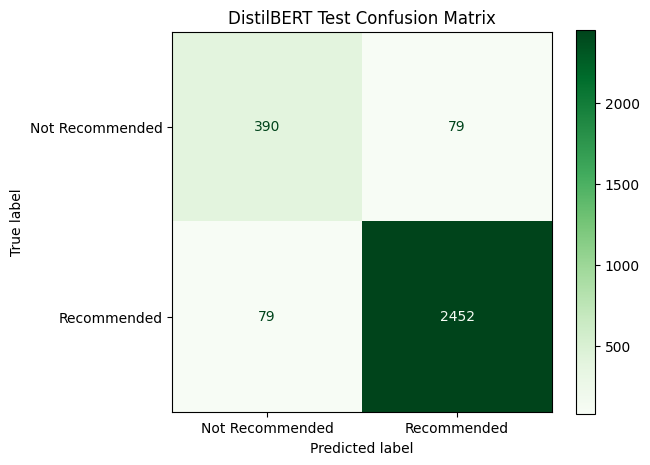

In [74]:
# DistilBERT confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_test_bert,
    y_pred_bert,
    display_labels=["Not Recommended", "Recommended"],
    cmap="Greens"
)

plt.title("DistilBERT Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [75]:
# Example DistilBERT predictions

sample_reviews = pd.DataFrame({
    "review_text": X_test_bert.values,
    "true_label": y_test_bert,
    "predicted_label": y_pred_bert
})

# Convert labels to readable text
label_map = {
    0: "Not Recommended",
    1: "Recommended"
}

sample_reviews["true_label"] = sample_reviews["true_label"].map(label_map)
sample_reviews["predicted_label"] = sample_reviews["predicted_label"].map(label_map)

# Show correctly predicted examples
correct_examples = sample_reviews[
    sample_reviews["true_label"] ==
    sample_reviews["predicted_label"]
].head(5)

correct_examples

,review_text,true_label,predicted_label
0,This has been my holy grail for years. It tran...,Recommended,Recommended
1,I love lip balms so I was very happy to try th...,Recommended,Recommended
2,These are nice - mine haven’t dried up and I’v...,Not Recommended,Not Recommended
3,At first when i bought it it was working reall...,Not Recommended,Not Recommended
4,"OMG!! so amazing, helps with imperfections on ...",Recommended,Recommended


In [76]:
# Compare all models on SAME DistilBERT subset

# Transform same DistilBERT test reviews using TF-IDF
X_test_bert_tfidf = tfidf.transform(X_test_bert)

# Logistic Regression predictions
logistic_test_pred = logistic_model.predict(X_test_bert_tfidf)

# Linear SVM predictions
svm_test_pred = svm_model.predict(X_test_bert_tfidf)

# Evaluate Logistic Regression
logistic_same_results = evaluate_model(
    "Logistic Regression",
    y_test_bert,
    logistic_test_pred
)

# Evaluate Linear SVM
svm_same_results = evaluate_model(
    "Linear SVM",
    y_test_bert,
    svm_test_pred
)

# DistilBERT results
distilbert_same_results = {
    "Model": "DistilBERT",
    "Accuracy": distilbert_test_results["eval_accuracy"],
    "Precision": distilbert_test_results["eval_precision"],
    "Recall": distilbert_test_results["eval_recall"],
    "F1-score": distilbert_test_results["eval_f1"]
}

# Create comparison dataframe
same_subset_results = pd.DataFrame([
    logistic_same_results,
    svm_same_results,
    distilbert_same_results
])

same_subset_results


Logistic Regression Results
----------------------------------------
Accuracy: 0.8957
Precision: 0.9756
Recall: 0.8989
F1-score: 0.9356

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.88      0.72       469
           1       0.98      0.90      0.94      2531

    accuracy                           0.90      3000
   macro avg       0.80      0.89      0.83      3000
weighted avg       0.92      0.90      0.90      3000


Linear SVM Results
----------------------------------------
Accuracy: 0.9023
Precision: 0.9706
Recall: 0.9119
F1-score: 0.9403

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.85      0.73       469
           1       0.97      0.91      0.94      2531

    accuracy                           0.90      3000
   macro avg       0.81      0.88      0.84      3000
weighted avg       0.92      0.90      0.91      3000



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.895667,0.975557,0.898854,0.935636
1,Linear SVM,0.902333,0.970563,0.911893,0.940314
2,DistilBERT,0.947333,0.968787,0.968787,0.968787


In [77]:
# Misclassified review examples

incorrect_examples = sample_reviews[
    sample_reviews["true_label"] !=
    sample_reviews["predicted_label"]
].head(5)

incorrect_examples

,review_text,true_label,predicted_label
15,I think it feels nice on the skin when washing...,Not Recommended,Recommended
22,I tried the biossance gel moisturizer first an...,Not Recommended,Recommended
76,I have somewhat sensitive skin but was looking...,Not Recommended,Recommended
88,Oddly thick and would not recommend for over-t...,Not Recommended,Recommended
90,I bought this because I was looking for someth...,Not Recommended,Recommended


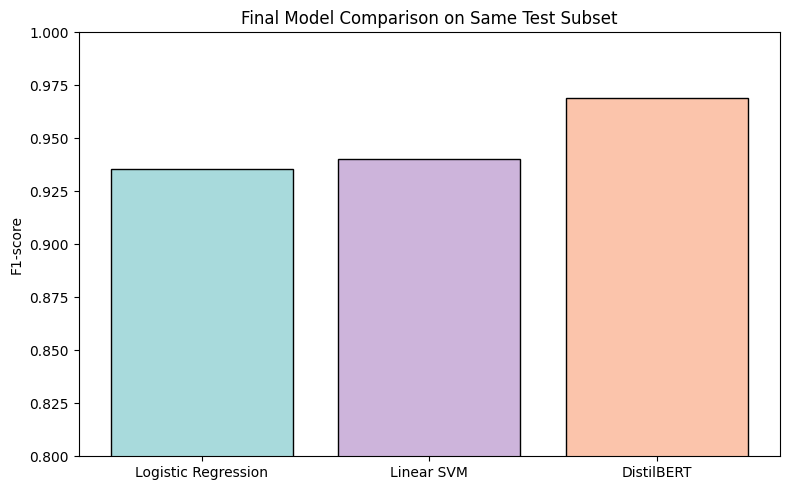

In [78]:
# Final fair comparison graph

plt.figure(figsize=(8,5))

plt.bar(
    same_subset_results["Model"],
    same_subset_results["F1-score"],
    color=["#A8DADC", "#CDB4DB", "#FBC4AB"],
    edgecolor="black"
)

plt.title("Final Model Comparison on Same Test Subset")
plt.ylabel("F1-score")
plt.ylim(0.80, 1.00)

plt.tight_layout()
plt.show()

In [79]:
# Computed DistilBERT training diagnostics

history_df = pd.DataFrame(trainer.state.log_history)

# Training loss values recorded during training
loss_history = history_df.dropna(subset=["loss"])[["step", "loss"]].copy()

# Validation metrics recorded at each epoch
eval_history = history_df.dropna(subset=["eval_f1"])[
    ["epoch", "eval_loss", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]
].drop_duplicates(subset=["epoch"]).sort_values("epoch")

eval_history

,epoch,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1
15,1.0,0.156783,0.943667,0.954580,0.979850,0.967050
31,2.0,0.179164,0.950000,0.971859,0.968787,0.970321
47,3.0,0.205870,0.951333,0.968934,0.973528,0.971226


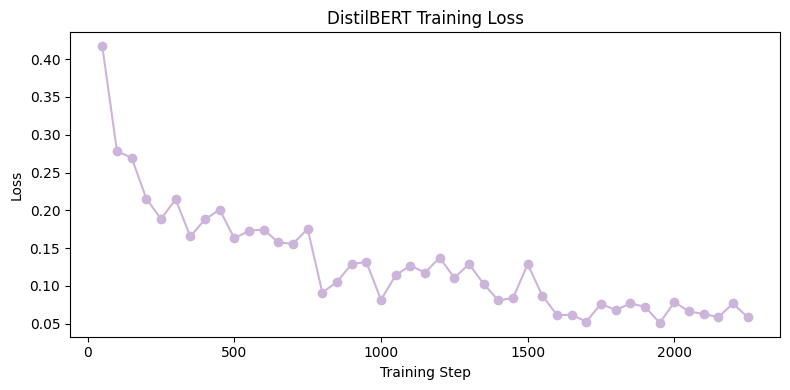

In [80]:
# DistilBERT training loss graph

plt.figure(figsize=(8, 4))

plt.plot(
    loss_history["step"],
    loss_history["loss"],
    marker="o",
    color="#CDB4DB"
)

plt.title("DistilBERT Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

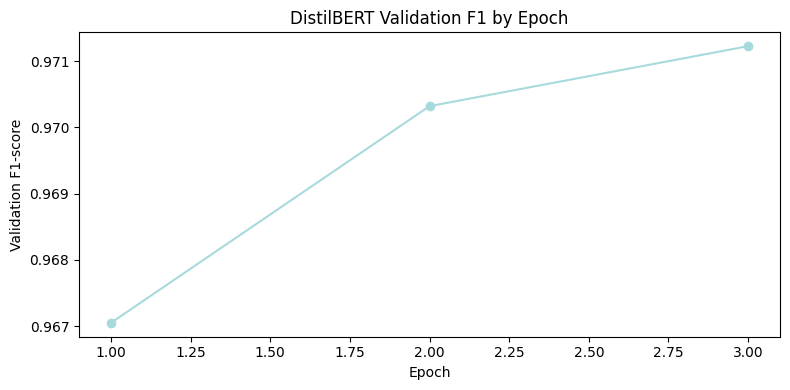

In [81]:
# DistilBERT validation F1 by epoch

plt.figure(figsize=(8, 4))

plt.plot(
    eval_history["epoch"],
    eval_history["eval_f1"],
    marker="o",
    color="#A8DADC"
)

plt.title("DistilBERT Validation F1 by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation F1-score")

plt.tight_layout()
plt.show()

# Hybrid Model

In [82]:
# Hybrid DistilBERT + metadata helper functions

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.sparse import csr_matrix, hstack

def extract_cls_embeddings(texts, tokenizer, model, batch_size=32, max_length=128):
    """
    Extract DistilBERT [CLS]-style embeddings from review text.
    These embeddings represent contextual review meaning.
    """

    model.eval()
    model_device = next(model.parameters()).device

    texts = list(texts)
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(model_device)
            for key, value in encoded.items()
        }

        with torch.no_grad():
            outputs = model.distilbert(**encoded)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

In [83]:
# Metadata preprocessing for hybrid model

def build_metadata_preprocessor():
    """
    Preprocess review metadata.
    review_length is scaled.
    skin_type is one-hot encoded.
    """

    numeric_features = ["review_length"]
    categorical_features = ["skin_type"]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    return preprocessor

In [84]:
# Extract DistilBERT embeddings

train_embeddings = extract_cls_embeddings(
    X_train_bert,
    tokenizer,
    distilbert_model
)

test_embeddings = extract_cls_embeddings(
    X_test_bert,
    tokenizer,
    distilbert_model
)

print("Train embedding shape:", train_embeddings.shape)
print("Test embedding shape:", test_embeddings.shape)

Train embedding shape: (12000, 768)
Test embedding shape: (3000, 768)


In [85]:
# Train hybrid DistilBERT + metadata model

metadata_preprocessor = build_metadata_preprocessor()

metadata_columns = ["review_length", "skin_type"]

X_train_metadata = metadata_preprocessor.fit_transform(
    meta_train_bert[metadata_columns]
)

X_test_metadata = metadata_preprocessor.transform(
    meta_test_bert[metadata_columns]
)

# Combine transformer embeddings with metadata features
X_train_hybrid = hstack([
    csr_matrix(train_embeddings),
    X_train_metadata
])

X_test_hybrid = hstack([
    csr_matrix(test_embeddings),
    X_test_metadata
])

hybrid_model = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED
)

hybrid_model.fit(
    X_train_hybrid,
    y_train_bert
)

hybrid_pred = hybrid_model.predict(
    X_test_hybrid
)

hybrid_results = evaluate_model(
    "Hybrid DistilBERT + metadata",
    y_test_bert,
    hybrid_pred
)


Hybrid DistilBERT + metadata Results
----------------------------------------
Accuracy: 0.9413
Precision: 0.9712
Recall: 0.9589
F1-score: 0.965

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       469
           1       0.97      0.96      0.97      2531

    accuracy                           0.94      3000
   macro avg       0.88      0.90      0.89      3000
weighted avg       0.94      0.94      0.94      3000



In [86]:
# Metadata-only ablation

metadata_only_model = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED
)

metadata_only_model.fit(
    X_train_metadata,
    y_train_bert
)

metadata_only_pred = metadata_only_model.predict(
    X_test_metadata
)

metadata_only_results = evaluate_model(
    "Metadata only",
    y_test_bert,
    metadata_only_pred
)


Metadata only Results
----------------------------------------
Accuracy: 0.6513
Precision: 0.8417
Recall: 0.7226
F1-score: 0.7776

Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.27      0.19       469
           1       0.84      0.72      0.78      2531

    accuracy                           0.65      3000
   macro avg       0.50      0.49      0.49      3000
weighted avg       0.73      0.65      0.69      3000



In [87]:
# Final ablation results table

distilbert_results = {
    "Model": "DistilBERT text only",
    "Accuracy": distilbert_test_results["eval_accuracy"],
    "Precision": distilbert_test_results["eval_precision"],
    "Recall": distilbert_test_results["eval_recall"],
    "F1-score": distilbert_test_results["eval_f1"]
}

ablation_results = pd.DataFrame([
    controlled_logistic_results,
    controlled_svm_results,
    distilbert_results,
    metadata_only_results,
    hybrid_results
])

ablation_results

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression controlled split,0.888000,0.964452,0.900435,0.931345
1,TF-IDF + Linear SVM controlled split,0.902000,0.952651,0.930067,0.941224
2,DistilBERT text only,0.947333,0.968787,0.968787,0.968787
3,Metadata only,0.651333,0.841694,0.722639,0.777636
4,Hybrid DistilBERT + metadata,0.941333,0.971188,0.958910,0.965010


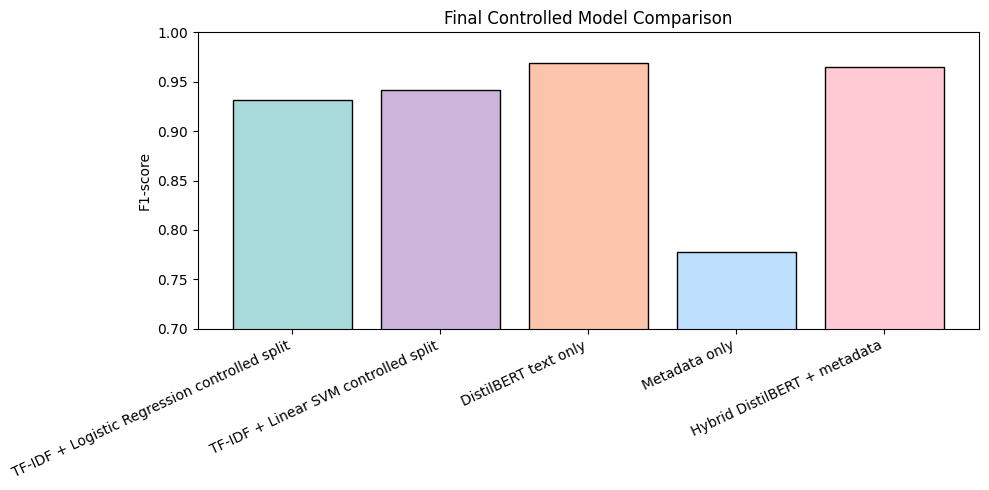

In [88]:
# Final controlled model comparison

plt.figure(figsize=(10, 5))

plt.bar(
    ablation_results["Model"],
    ablation_results["F1-score"],
    color=["#A8DADC", "#CDB4DB", "#FBC4AB", "#BDE0FE", "#FFCAD4"],
    edgecolor="black"
)

plt.title("Final Controlled Model Comparison")
plt.ylabel("F1-score")
plt.ylim(0.70, 1.00)

plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()